In [6]:
# Cell 1 - 로드 및 구조 확인

import pandas as pd

# 파일 경로는 본인 환경에 맞게 조정해주세요 ~! 
경로 = r'C:\DI\[프로젝트2] 데이터 분석 대시보드 제작\Data\원본 데이터'

portfolio  = pd.read_json(f'{경로}\\portfolio.json',  orient='records', lines=True)
profile    = pd.read_json(f'{경로}\\profile.json',    orient='records', lines=True)
transcript = pd.read_json(f'{경로}\\transcript.json', orient='records', lines=True)

print("=== 테이블 크기 ===")
print(f"portfolio: {portfolio.shape}, profile: {profile.shape}, transcript: {transcript.shape}")

print("\n=== event 종류별 건수 ===")
print(transcript['event'].value_counts())

print("\n=== event 종류별 value 딕셔너리 예시 (키 이름 확인용) ===")
for ev in transcript['event'].unique():
    example = transcript.loc[transcript['event'] == ev, 'value'].iloc[0]
    print(f"- {ev}: {example}")

=== 테이블 크기 ===
portfolio: (10, 6), profile: (17000, 5), transcript: (306534, 4)

=== event 종류별 건수 ===
event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

=== event 종류별 value 딕셔너리 예시 (키 이름 확인용) ===
- offer received: {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
- offer viewed: {'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}
- transaction: {'amount': 0.8300000000000001}
- offer completed: {'offer_id': '2906b810c7d4411798c6938adc9daaa5', 'reward': 2}


In [7]:
portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [8]:
profile

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


In [9]:
transcript

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


In [10]:
# Cell 2 — 증상 확인: 전체 오퍼 완료율 + 오퍼 타입별 완료율

def extract_offer_id(value_dict):
    # 이벤트에 따라 키 이름이 다르게 기록된다고 알려져 있어 두 경우 모두 처리
    return value_dict.get('offer id', value_dict.get('offer_id'))

offer_events = transcript[transcript['event'] != 'transaction'].copy()
offer_events['offer_id'] = offer_events['value'].apply(extract_offer_id)

# 1) 전체 오퍼 완료율 (아주 단순 비율 — 인과/기여도 분석 아님, 증상 확인용)
n_수신 = (offer_events['event'] == 'offer received').sum()
n_완료 = (offer_events['event'] == 'offer completed').sum()
print(f"=== 전체 오퍼 완료율 ===")
print(f"수신 {n_수신}건 / 완료 {n_완료}건 → 완료율 {n_완료 / n_수신 * 100:.1f}%")

# 2) 오퍼 타입별 완료율
merged = offer_events.merge(
    portfolio[['id', 'offer_type']],
    left_on='offer_id', right_on='id', how='left'
)
표 = merged.groupby('offer_type')['event'].value_counts().unstack(fill_value=0)
표['완료율(%)'] = (표.get('offer completed', 0) / 표.get('offer received', 1) * 100).round(1)
print("\n=== 오퍼 타입별 완료율 ===")
print(표)

=== 전체 오퍼 완료율 ===
수신 76277건 / 완료 33579건 → 완료율 44.0%

=== 오퍼 타입별 완료율 ===
event          offer completed  offer received  offer viewed  완료율(%)
offer_type                                                          
bogo                     15669           30499         25449    51.4
discount                 17910           30543         21445    58.6
informational                0           15235         10831     0.0


EDA 순서 : 
1) profile(고객) 품질 체크 → 이 데이터셋은 age=118 같은 결측 대체값, gender/income 동반 결측 같은 알려진 이슈가 있어서 제일 먼저 봐야 함. 세그먼트 기반 가설(H3 계열)의 신뢰도가 여기서 갈림.
2) portfolio 프로파일링 → 테이블이 10행뿐이라 가볍게, difficulty/reward/duration 분포와 channels 구성만 확인.
3) transcript 참조무결성 → person이 profile에 다 있는지, offer_id가 portfolio에 다 있는지, 중복 이벤트 여부, 전체 기간(time) 범위.

In [11]:
# Cell 3 — profile 품질 체크

print("=== profile 결측치 비율(%) ===")
print((profile.isnull().mean() * 100).round(1))

print("\n=== gender 분포 (결측 포함) ===")
print(profile['gender'].value_counts(dropna=False))

print("\n=== age 분포 요약 ===")
print(profile['age'].describe())
print(f"\nage == 118 인 비율: {(profile['age'] == 118).mean() * 100:.1f}%")

print("\n=== income 분포 요약 ===")
print(profile['income'].describe())

# age==118(결측 대체값 의심)과 income/gender 결측이 같이 붙어다니는지 확인
print("\n=== age==118 여부 x income 결측 여부 교차표 ===")
print(pd.crosstab(profile['age'] == 118, profile['income'].isnull()))

print("\n=== became_member_on 범위 ===")
가입일 = pd.to_datetime(profile['became_member_on'], format='%Y%m%d')
print(f"최소: {가입일.min()}, 최대: {가입일.max()}")

print("\n=== id 중복 여부 ===")
print(f"고유 id 수: {profile['id'].nunique()} / 전체 행 수: {len(profile)}")

=== profile 결측치 비율(%) ===
gender              12.8
age                  0.0
id                   0.0
became_member_on     0.0
income              12.8
dtype: float64

=== gender 분포 (결측 포함) ===
gender
M      8484
F      6129
NaN    2175
O       212
Name: count, dtype: int64

=== age 분포 요약 ===
count    17000.000000
mean        62.531412
std         26.738580
min         18.000000
25%         45.000000
50%         58.000000
75%         73.000000
max        118.000000
Name: age, dtype: float64

age == 118 인 비율: 12.8%

=== income 분포 요약 ===
count     14825.000000
mean      65404.991568
std       21598.299410
min       30000.000000
25%       49000.000000
50%       64000.000000
75%       80000.000000
max      120000.000000
Name: income, dtype: float64

=== age==118 여부 x income 결측 여부 교차표 ===
income  False  True 
age                 
False   14825      0
True        0   2175

=== became_member_on 범위 ===
최소: 2013-07-29 00:00:00, 최대: 2018-07-26 00:00:00

=== id 중복 여부 ===
고유 id 수: 17000 / 전체 행 수: 1

| 항목 | 처리 내용 | 이유 |
|---|---|---|
| 프로필 미입력 고객 | `age==118`을 기준으로 `프로필입력여부`(입력/미입력) 컬럼 신규 생성, 별도 세그먼트로 유지 | age=118, gender 결측, income 결측이 완전히 같은 12.8%(2,175명)에서 발생 — 무작위 결측이 아니라 의미 있는 고객군이므로 삭제하지 않고 별도 세그먼트로 분리 |
| gender 'O' | EDA/시각화 단계에서는 M/F/O/미입력 그대로 표시, 통계 검정 단계에서는 O+미입력을 '기타'로 묶은 `성별_통계용` 컬럼 별도 생성 | O가 212명(전체 1.2%)뿐이라 통계 검정 시 표본 부족으로 신뢰구간이 지나치게 넓어질 수 있음 |
| income | 사분위수(25/50/75%) 기준 4구간 + '미입력' 카테고리로 `소득구간` 컬럼 생성 | min/max가 정확히 30,000/120,000으로 딱 떨어져 캡핑(capping) 가능성 있음 — 연속값 그대로 쓰기보다 구간화가 안전 |
| 가입 경과일(tenure) | `became_member_on`의 최댓값(2018-07-26)을 관찰 시점 근사치로 삼아 `가입경과일` = 근사 관찰시점 − 가입일로 계산 | transcript의 `time`이 절대 날짜가 아닌 관찰 시작 후 경과 시간(상대값)이라 정확한 절대 tenure 계산 불가 — 근사치로 상대적 신규/기존 정도만 비교 |

In [12]:
# Cell 4 — 세그먼트 컬럼 생성 + 분포 확인

import numpy as np

profile_전처리 = profile.copy()

# 1. 프로필 입력 여부
profile_전처리['프로필입력여부'] = np.where(profile_전처리['age'] == 118, '미입력', '입력')

# 2. 성별 (EDA용 원본 유지 + 통계용 별도 컬럼)
profile_전처리['성별_EDA'] = profile_전처리['gender'].fillna('미입력')
profile_전처리['성별_통계용'] = profile_전처리['성별_EDA'].replace({'O': '기타', '미입력': '기타'})

# 3. income 구간화 (사분위수 기준 4구간 + 미입력)
q1, q2, q3 = profile_전처리['income'].quantile([0.25, 0.5, 0.75])

def 소득구간화(x):
    if pd.isnull(x):
        return '미입력'
    elif x <= q1:
        return f'하위 25% (~{int(q1):,})'
    elif x <= q2:
        return f'25~50% ({int(q1):,}~{int(q2):,})'
    elif x <= q3:
        return f'50~75% ({int(q2):,}~{int(q3):,})'
    else:
        return f'상위 25% ({int(q3):,}~)'

profile_전처리['소득구간'] = profile_전처리['income'].apply(소득구간화)

# 4. 가입 경과일 (tenure) — 관찰 시점 근사치로 became_member_on 최댓값 사용
profile_전처리['가입일'] = pd.to_datetime(profile_전처리['became_member_on'], format='%Y%m%d')
관찰시점_근사 = profile_전처리['가입일'].max()
profile_전처리['가입경과일'] = (관찰시점_근사 - profile_전처리['가입일']).dt.days
profile_전처리['가입연도'] = profile_전처리['가입일'].dt.year

# --- 결과 확인 ---
print("=== 프로필입력여부 분포 ===")
print(profile_전처리['프로필입력여부'].value_counts())

print("\n=== 소득구간 분포 ===")
print(profile_전처리['소득구간'].value_counts())

print("\n=== 성별_통계용 분포 ===")
print(profile_전처리['성별_통계용'].value_counts())

print("\n=== 가입경과일 요약 (프로필 입력된 고객만) ===")
print(profile_전처리.loc[profile_전처리['프로필입력여부'] == '입력', '가입경과일'].describe())

print("\n=== 프로필입력여부 x 가입연도 교차표 (미입력이 특정 시기에 몰려있는지 확인) ===")
print(pd.crosstab(profile_전처리['프로필입력여부'], profile_전처리['가입연도']))

# 파일로 저장 — 원본 파일(profile.json)은 절대 덮어쓰지 않고 새 이름으로 저장
profile_전처리.to_csv('profile_전처리.csv', index=False, encoding='utf-8-sig')

=== 프로필입력여부 분포 ===
프로필입력여부
입력     14825
미입력     2175
Name: count, dtype: int64

=== 소득구간 분포 ===
소득구간
25~50% (49,000~64,000)    3863
하위 25% (~49,000)          3781
50~75% (64,000~80,000)    3616
상위 25% (80,000~)          3565
미입력                       2175
Name: count, dtype: int64

=== 성별_통계용 분포 ===
성별_통계용
M     8484
F     6129
기타    2387
Name: count, dtype: int64

=== 가입경과일 요약 (프로필 입력된 고객만) ===
count    14825.000000
mean       522.478988
std        419.205158
min          0.000000
25%        208.000000
50%        358.000000
75%        797.000000
max       1823.000000
Name: 가입경과일, dtype: float64

=== 프로필입력여부 x 가입연도 교차표 (미입력이 특정 시기에 몰려있는지 확인) ===
가입연도     2013  2014  2015  2016  2017  2018
프로필입력여부                                    
미입력        12    29   233   502   870   529
입력        274   662  1597  3024  5599  3669


In [13]:
#Cell 5 — portfolio EDA

print("=== portfolio 전체 (10개 오퍼) ===")
print(portfolio)

print("\n=== offer_type별 개수 ===")
print(portfolio['offer_type'].value_counts())

print("\n=== difficulty / reward / duration 요약 ===")
print(portfolio[['difficulty', 'reward', 'duration']].describe())

print("\n=== id 중복 확인 ===")
print(f"고유 id 수: {portfolio['id'].nunique()} / 전체 행 수: {len(portfolio)}")

print("\n=== channels 컬럼 (리스트 형태) 확인 ===")
for _, row in portfolio.iterrows():
    print(f"{row['offer_type']:15s} | difficulty={row['difficulty']:>3} reward={row['reward']:>3} duration={row['duration']:>2} | channels={row['channels']}")

print("\n=== channels에 등장하는 모든 고유 채널 ===")
전체채널 = set()
for ch_list in portfolio['channels']:
    전체채널.update(ch_list)
print(전체채널)

print("\n=== 채널 개수(오퍼당 몇 개 채널로 발송됐는지) ===")
print(portfolio['channels'].apply(len).value_counts().sort_index())

=== portfolio 전체 (10개 오퍼) ===
   reward                      channels  difficulty  duration     offer_type  \
0      10       [email, mobile, social]          10         7           bogo   
1      10  [web, email, mobile, social]          10         5           bogo   
2       0          [web, email, mobile]           0         4  informational   
3       5          [web, email, mobile]           5         7           bogo   
4       5                  [web, email]          20        10       discount   
5       3  [web, email, mobile, social]           7         7       discount   
6       2  [web, email, mobile, social]          10        10       discount   
7       0       [email, mobile, social]           0         3  informational   
8       5  [web, email, mobile, social]           5         5           bogo   
9       2          [web, email, mobile]          10         7       discount   

                                 id  
0  ae264e3637204a6fb9bb56bc8210ddfd  
1  4d5c57ea9a

| 항목 | 처리 내용 | 이유 |
|---|---|---|
| channels 원-핫 인코딩 | `channels`(리스트)에서 web/mobile/social 3개만 0/1 컬럼으로 생성 (email 제외) | email은 10개 오퍼 전부에 포함되어 분산이 0인 상수 컬럼이라 채널 간 비교에 구분력이 없음 |
| 보상비율(매력도) | `reward / difficulty` 계산, `difficulty==0`인 informational은 NaN 처리 | 0으로 나누는 걸 방지하고, informational처럼 애초에 측정이 성립하지 않는 케이스를 '측정 불가'로 명시 (앞서 완료율 처리와 일관성 유지) |

In [14]:
# Cell 6 — portfolio 전처리 + CSV 저장

import numpy as np

portfolio_전처리 = portfolio.copy()

# 1. channels 원-핫 인코딩 (email은 상수라 제외, web/mobile/social만)
for 채널 in ['web', 'mobile', 'social']:
    portfolio_전처리[f'채널_{채널}'] = portfolio_전처리['channels'].apply(lambda x: 1 if 채널 in x else 0)

# 2. 보상비율(reward / difficulty), informational(difficulty=0)은 NaN 처리
portfolio_전처리['보상비율'] = np.where(
    portfolio_전처리['difficulty'] == 0,
    np.nan,
    portfolio_전처리['reward'] / portfolio_전처리['difficulty']
)

# --- 결과 확인 ---
print("=== 전처리 결과 확인 ===")
print(portfolio_전처리[['offer_type', 'difficulty', 'reward', 'duration',
                       '채널_web', '채널_mobile', '채널_social', '보상비율']])

print("\n=== offer_type별 보상비율 요약 ===")
print(portfolio_전처리.groupby('offer_type')['보상비율'].describe())

# --- CSV 저장 (원본 portfolio는 그대로 유지) ---
portfolio_전처리.to_csv('portfolio_전처리.csv', index=False, encoding='utf-8-sig')
print(f"\n저장 완료: portfolio_전처리.csv (원본 portfolio: {portfolio.shape}, 전처리본: {portfolio_전처리.shape})")

=== 전처리 결과 확인 ===
      offer_type  difficulty  reward  duration  채널_web  채널_mobile  채널_social  \
0           bogo          10      10         7       0          1          1   
1           bogo          10      10         5       1          1          1   
2  informational           0       0         4       1          1          0   
3           bogo           5       5         7       1          1          0   
4       discount          20       5        10       1          0          0   
5       discount           7       3         7       1          1          1   
6       discount          10       2        10       1          1          1   
7  informational           0       0         3       0          1          1   
8           bogo           5       5         5       1          1          1   
9       discount          10       2         7       1          1          0   

       보상비율  
0  1.000000  
1  1.000000  
2       NaN  
3  1.000000  
4  0.250000  
5  0.428571  
6  

In [15]:
# Cell 7 — transcript 참조무결성 및 구조 확인

print("=== transcript 기본 정보 ===")
print(transcript.shape)
print(transcript.dtypes)

# 1. person 참조무결성
transcript_person = set(transcript['person'].unique())
profile_id = set(profile['id'].unique())
print(f"\ntranscript 고유 person 수: {len(transcript_person)}")
print(f"profile에 없는 person 수: {len(transcript_person - profile_id)}")

# 2. offer_id 참조무결성 (오퍼 관련 이벤트만, 키 이름 두 가지 다 처리)
def offer_id_추출(value_dict):
    return value_dict.get('offer id', value_dict.get('offer_id'))

오퍼이벤트 = transcript[transcript['event'] != 'transaction'].copy()
오퍼이벤트['offer_id'] = 오퍼이벤트['value'].apply(offer_id_추출)

transcript_offer_id = set(오퍼이벤트['offer_id'].dropna().unique())
portfolio_id = set(portfolio['id'].unique())
print(f"\ntranscript(오퍼 이벤트)의 고유 offer_id 수: {len(transcript_offer_id)}")
print(f"portfolio에 없는 offer_id 수: {len(transcript_offer_id - portfolio_id)}")

# 3. 완전 중복 행 확인 (value가 dict라 그대로는 비교 불가 → 문자열로 변환해서 비교)
중복확인용 = transcript.copy()
중복확인용['value_str'] = 중복확인용['value'].astype(str)
print(f"완전 중복 행 수: {중복확인용.duplicated(subset=['person', 'event', 'time', 'value_str']).sum()}")

# 4. time 컬럼 분포 (관찰 시작 후 경과 시간, 단위: 시간)
print("\n=== time 컬럼 요약 ===")
print(transcript['time'].describe())
print(f"고유 time 값 개수: {transcript['time'].nunique()}")
print(f"최댓값을 일(day) 단위로 환산: {transcript['time'].max() / 24:.1f}일")

# 5. transaction 이벤트의 amount 분포 (나중에 매출 관련 지표에 쓰일 값)
거래이벤트 = transcript[transcript['event'] == 'transaction'].copy()
거래이벤트['amount'] = 거래이벤트['value'].apply(lambda x: x.get('amount'))
print("\n=== transaction amount 요약 ===")
print(거래이벤트['amount'].describe())

=== transcript 기본 정보 ===
(306534, 4)
person       str
event        str
value     object
time       int64
dtype: object



transcript 고유 person 수: 17000
profile에 없는 person 수: 0

transcript(오퍼 이벤트)의 고유 offer_id 수: 10
portfolio에 없는 offer_id 수: 0
완전 중복 행 수: 397

=== time 컬럼 요약 ===
count    306534.000000
mean        366.382940
std         200.326314
min           0.000000
25%         186.000000
50%         408.000000
75%         528.000000
max         714.000000
Name: time, dtype: float64
고유 time 값 개수: 120
최댓값을 일(day) 단위로 환산: 29.8일

=== transaction amount 요약 ===
count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64


=== amount 상위 15건 ===
                                  person  time   amount
284273  6cf884a6c5ae4b2daccb6d3108028fef   630  1062.28
301790  454b00bdd77c4f588eb9f6cafd81dc5d   690  1015.73
42253   5ecaea5c8bf44ae4a65838d9d066c909   102  1001.85
140346  dce784e26f294101999d000fad9089bb   372   989.34
302951  52959f19113e4241a8cb3bef486c6412   696   977.78
294112  626df8678e2a4953b9098246418c9cfa   660   966.24
21490   c7a5d7bab83a4d82a7f977b3d586f3d4    18   962.10
280015  6406abad8e2c4b8584e4f68003de148d   618   961.21
280202  ef65dd061ff24b0f805a51dd0328dbcb   618   957.15
27692   a73cf044395d46ea804f688490ad9227    36   947.43
301271  9e523a3e05e14fd0bfec8ac108ce2cab   690   943.40
279852  d240308de0ee4cf8bb6072816268582b   618   943.33
43802   5dfdad4241764dfe959f51b7460e42b1   108   936.94
163752  f4e2258e9c23436e8db7dea8a2e12ec5   408   922.65
265808  ca715b3f17e24692b18f3cd90b9bf232   588   920.01

=== amount 1000 이상 건수 ===
3

=== amount 상위 1% 지점 ===
0.950     29.91000
0.990    

C:\Users\seoyeon\AppData\Local\Temp\ipykernel_31104\3346929962.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(거래이벤트['amount'], vert=True, patch_artist=True,
C:\Users\seoyeon\AppData\Local\Temp\ipykernel_31104\3346929962.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(거래이벤트['amount'], vert=True, patch_artist=True,
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for

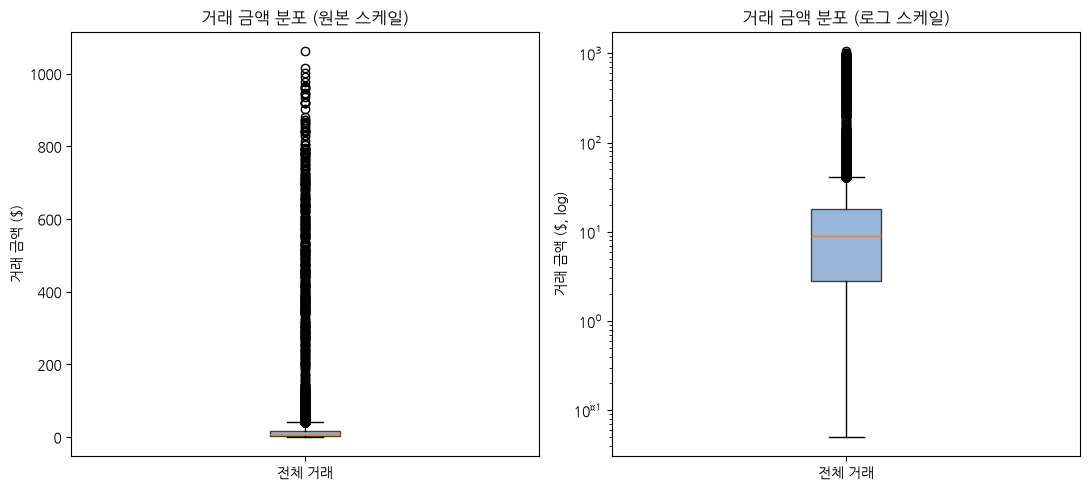

IQR 기준 이상치 상한: 41.00
상한 초과 건수: 1236 / 138953 (0.89%)


In [18]:
# Cell 7-1 — 고액 거래 상위 확인

print("=== amount 상위 15건 ===")
print(거래이벤트[['person', 'time', 'amount']].sort_values('amount', ascending=False).head(15))

print("\n=== amount 1000 이상 건수 ===")
print((거래이벤트['amount'] >= 1000).sum())

print("\n=== amount 상위 1% 지점 ===")
print(거래이벤트['amount'].quantile([0.95, 0.99, 0.999]))

# Cell 7-2 — 거래 금액 박스플롯

import matplotlib.pyplot as plt

# 방법 1 — 가장 간단 (권장): koreanize-matplotlib 패키지
!pip install koreanize-matplotlib -q
import koreanize_matplotlib  # import만 해도 한글 폰트 자동 설정됨

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 1. 원본 스케일 — 극단값이 얼마나 튀는지 그대로 보기
axes[0].boxplot(거래이벤트['amount'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#6E9BC9', alpha=0.7))
axes[0].set_title('거래 금액 분포 (원본 스케일)')
axes[0].set_ylabel('거래 금액 ($)')
axes[0].set_xticklabels(['전체 거래'])

# 2. 로그 스케일 — 박스(중간 50%) 자체의 모양을 보기 위함
axes[1].boxplot(거래이벤트['amount'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#6E9BC9', alpha=0.7))
axes[1].set_yscale('log')
axes[1].set_title('거래 금액 분포 (로그 스케일)')
axes[1].set_ylabel('거래 금액 ($, log)')
axes[1].set_xticklabels(['전체 거래'])

plt.tight_layout()
plt.savefig('거래금액_박스플롯.png', dpi=150)
plt.show()

# IQR 기준 이상치 개수도 참고로 확인
Q1, Q3 = 거래이벤트['amount'].quantile([0.25, 0.75])
IQR = Q3 - Q1
상한 = Q3 + 1.5 * IQR
print(f"IQR 기준 이상치 상한: {상한:.2f}")
print(f"상한 초과 건수: {(거래이벤트['amount'] > 상한).sum()} / {len(거래이벤트)} ({(거래이벤트['amount'] > 상한).mean()*100:.2f}%)")

| 항목 | 처리 내용 | 이유 |
|---|---|---|
| 완전 중복 행 제거 | person·event·value·time이 모두 동일한 397건(0.13%) 삭제 | 로그 적재 과정에서 발생한 중복으로 판단, 비중이 작아 전체 결과에 미치는 영향이 미미함 |

In [19]:
#Cell 8 — transcript 전처리 + CSV 저장

# value(dict) 컬럼은 그대로 두고, 비교용 문자열만 임시로 만들어서 중복 판별
_value_str = transcript['value'].astype(str)

중복여부 = transcript.duplicated(subset=['person', 'event', 'time']) & (
    transcript.assign(_v=_value_str).duplicated(subset=['person', 'event', 'time', '_v'])
)

# 더 간단하게: person/event/time/value문자열 네 개 기준으로 바로 판별
중복여부 = transcript.assign(_v=_value_str).duplicated(subset=['person', 'event', 'time', '_v'])

transcript_전처리 = transcript[~중복여부].reset_index(drop=True)

print(f"원본 transcript: {transcript.shape}")
print(f"중복 제거 후: {transcript_전처리.shape}")
print(f"제거된 행 수: {(~중복여부 == False).sum()}")

# CSV 저장 (원본 transcript는 그대로 유지)
transcript_전처리.to_csv('transcript_전처리.csv', index=False, encoding='utf-8-sig')
print("\n저장 완료: transcript_전처리.csv")

원본 transcript: (306534, 4)
중복 제거 후: (306137, 4)
제거된 행 수: 397

저장 완료: transcript_전처리.csv
